### Imports

In [1]:
# Import des outils de tables
import pandas as pd
import numpy as np
import kagglehub

# Import des modèles
from tabicl import TabICLForecaster # https://github.com/soda-inria/tabicl
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

# Import des métriques d'évaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

### Téléchargement du dataset

In [2]:
df = kagglehub.dataset_load(
    kagglehub.KaggleDatasetAdapter.PANDAS,
    "chirag19/air-passengers",
    "AirPassengers.csv"
)

df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


### Conversion ETL

In [3]:
# Mise au format attendu par TabICL
df = df.rename(columns={
    "Month": "timestamp",
    "#Passengers": "target"
})

df["timestamp"] = pd.to_datetime(df["timestamp"])
df["item_id"] = 0

# Tri chronologique
df = df.sort_values("timestamp").reset_index(drop=True)

### Séparation en train, test

In [4]:
# Index de séparation chronologique (80 % / 20 %)
split_idx = int(len(df) * 0.80)

# Séparation chronologique des données
X_train = df.iloc[:split_idx].copy()
X_test = df.iloc[split_idx:].copy()

y_train = X_train["target"]
y_test = X_test["target"]

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

# Préparation des données pour Prophet
X_train_prophet = X_train[["timestamp", "target"]].rename(
    columns={"timestamp": "ds", "target": "y"})

X_test_prophet = X_test[["timestamp", "target"]].rename(
    columns={"timestamp": "ds", "target": "y"})

(115, 3)
(29, 3)
(115,)
(29,)


### Prédiction avec TFM ( Tabular Foundation Model )

In [ ]:
model_tfm = TabICLForecaster()

y_pred_tfm = model_tfm.predict_df(
    X_train,
    prediction_length=len(X_test)
)

### Prédiction avec Sarimax

In [ ]:
model_sarimax = SARIMAX(
    y_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)
)

model_sarimax = model_sarimax.fit()

y_pred_sarimax = model_sarimax.forecast(
    steps=len(y_test)
)

### Prédiction avec Prophet

In [ ]:
model_prophet = Prophet()

model_prophet.fit(X_train_prophet)

y_pred_prophet = model_prophet.predict(
    X_test_prophet[["ds"]]
)["yhat"]

### Évaluation des résultats

In [8]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(np.where(denominator == 0, 0, np.abs(y_true - y_pred) / denominator))

# ------------------------------------------------------------
# Métriques du TFM (TabICL)
# Prédictions stockées dans : y_pred_tfm
# ------------------------------------------------------------

mae_tfm = mean_absolute_error(y_test, y_pred_tfm["target"])
rmse_tfm = mean_squared_error(y_test, y_pred_tfm["target"]) ** 0.5
smape_tfm = smape(y_test, y_pred_tfm["target"])

# ------------------------------------------------------------
# Métriques du SARIMAX
# Prédictions stockées dans : y_pred_sarimax
# ------------------------------------------------------------

mae_sarimax = mean_absolute_error(y_test, y_pred_sarimax)
rmse_sarimax = mean_squared_error(y_test, y_pred_sarimax) ** 0.5
smape_sarimax = smape(y_test, y_pred_sarimax)

# ------------------------------------------------------------
# Métriques de Prophet
# Prédictions stockées dans : y_pred_prophet
# ------------------------------------------------------------

mae_prophet = mean_absolute_error(y_test, y_pred_prophet)
rmse_prophet = mean_squared_error(y_test, y_pred_prophet) ** 0.5
smape_prophet = smape(y_test, y_pred_prophet)

### Tableau Comparatif

In [9]:
resultats = pd.DataFrame({

    "Métrique": [
        "MAE",
        "RMSE",
        "sMAPE"
    ],

    "TFM (TabICL)": [
        mae_tfm,
        rmse_tfm,
        smape_tfm
    ],

    "SARIMAX": [
        mae_sarimax,
        rmse_sarimax,
        smape_sarimax
    ],

    "Prophet": [
        mae_prophet,
        rmse_prophet,
        smape_prophet
    ],

    "Description": [
        "MAE : plus proche de 0 = meilleur",
        "RMSE : plus proche de 0 = meilleur",
        "sMAPE : plus proche de 0 = meilleur"
    ]
})

# Formate les scores pour faciliter la lecture
def format_nombre(x):
    if abs(x) >= 1:
        return f"{x:_.0f}".replace("_", " ")
    else:
        return f"{x:.3f}"


resultats["TFM (TabICL)"] = resultats["TFM (TabICL)"].apply(format_nombre)
resultats["SARIMAX"] = resultats["SARIMAX"].apply(format_nombre)
resultats["Prophet"] = resultats["Prophet"].apply(format_nombre)

# Désactiver la notation scientifique
pd.options.display.float_format = '{:.3f}'.format

# Affichage du tableau comparatif
resultats

,Métrique,TFM (TabICL),SARIMAX,Prophet,Description
0,MAE,49,24,34,MAE : plus proche de 0 = meilleur
1,RMSE,60,30,41,RMSE : plus proche de 0 = meilleur
2,sMAPE,0.117,0.052,0.077,sMAPE : plus proche de 0 = meilleur


Text(0, 0.5, 'Nombre de passagers')

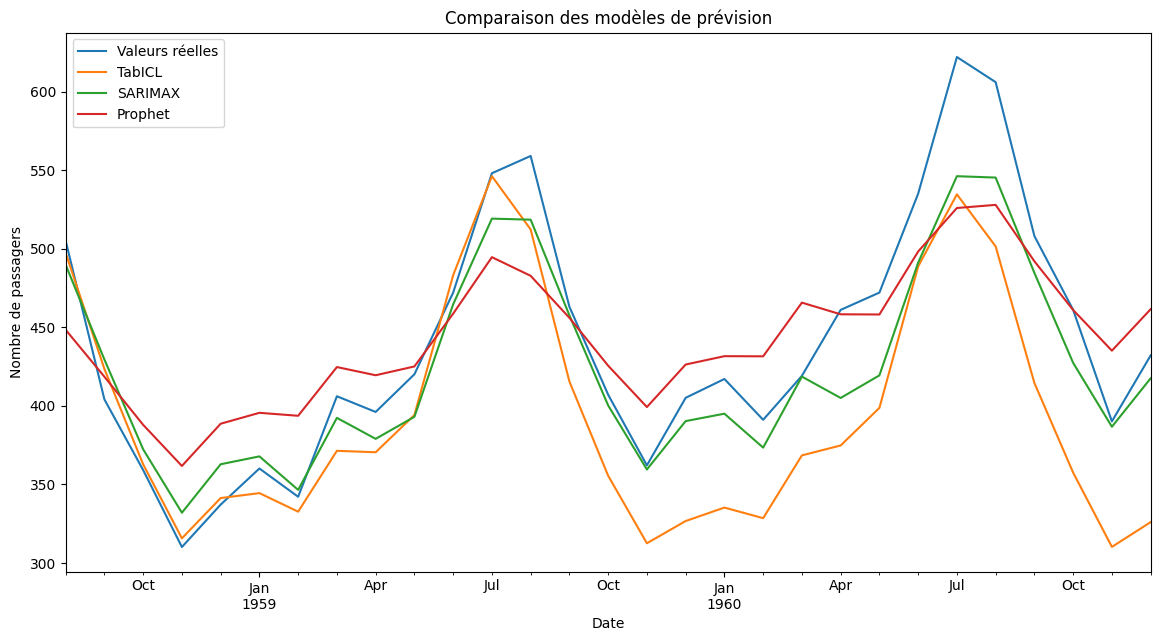

In [10]:
resultats = pd.DataFrame({
    "timestamp": X_test["timestamp"].reset_index(drop=True),
    "y_test": y_test.reset_index(drop=True),
    "y_pred_tfm": y_pred_tfm["target"].reset_index(drop=True),
    "y_pred_sarimax": y_pred_sarimax.reset_index(drop=True),
    "y_pred_prophet": y_pred_prophet.reset_index(drop=True)
})

ax = resultats.plot(
    x="timestamp",
    y=[
        "y_test",
        "y_pred_tfm",
        "y_pred_sarimax",
        "y_pred_prophet"
    ],
    figsize=(14, 7),
    title="Comparaison des modèles de prévision"
)

ax.legend([
    "Valeurs réelles",
    "TabICL",
    "SARIMAX",
    "Prophet"
])

ax.set_xlabel("Date")
ax.set_ylabel("Nombre de passagers")